# 📧 AI-Driven Phishing Email Detection
## Using NLP and Machine Learning
**Author:** Shreya G Amin   
**Date:** July 2026

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/phishing_email.csv")
print("Dataset loaded!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded!
Shape: (18650, 3)


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [4]:
df.info()
df.isnull().sum()
df["Email Type"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB


Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

C:\Users\shrey\AppData\Local\Temp\ipykernel_29064\2358018704.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Email Type", data=df, palette="coolwarm")


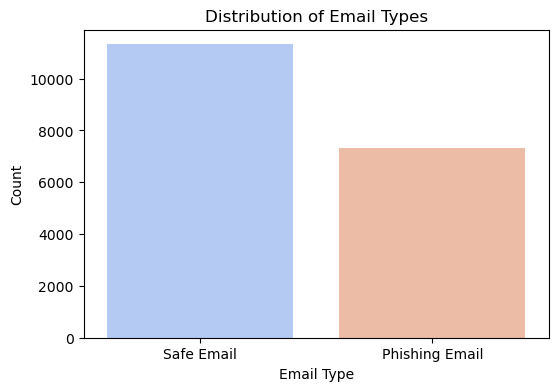

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Email Type", data=df, palette="coolwarm")
plt.title("Distribution of Email Types")
plt.xlabel("Email Type")
plt.ylabel("Count")
plt.show()

In [6]:
import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df["cleaned_text"] = df["Email Text"].apply(preprocess_text)
df["label"] = (df["Email Type"] == "Phishing Email").astype(int)

print("Preprocessing complete!")
print(df["label"].value_counts())

Preprocessing complete!
label
0    11322
1     7328
Name: count, dtype: int64


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df["cleaned_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training shape: {X_train_tfidf.shape}")
print(f"Testing shape: {X_test_tfidf.shape}")

Training shape: (14920, 5000)
Testing shape: (3730, 5000)


In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_pred)
print(f"Naive Bayes Accuracy: {nb_accuracy*100:.2f}%")
print(classification_report(y_test, nb_pred,
      target_names=["Safe", "Phishing"]))

Naive Bayes Accuracy: 95.52%
              precision    recall  f1-score   support

        Safe       0.97      0.96      0.96      2273
    Phishing       0.94      0.95      0.94      1457

    accuracy                           0.96      3730
   macro avg       0.95      0.95      0.95      3730
weighted avg       0.96      0.96      0.96      3730



In [9]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")
print(classification_report(y_test, lr_pred,
      target_names=["Safe", "Phishing"]))

Logistic Regression Accuracy: 96.68%
              precision    recall  f1-score   support

        Safe       0.98      0.97      0.97      2273
    Phishing       0.95      0.96      0.96      1457

    accuracy                           0.97      3730
   macro avg       0.96      0.97      0.97      3730
weighted avg       0.97      0.97      0.97      3730



In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=50, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
rf_pred = rf_model.predict(X_test_tfidf)

rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy*100:.2f}%")
print(classification_report(y_test, rf_pred,
      target_names=["Safe", "Phishing"]))

Random Forest Accuracy: 95.76%
              precision    recall  f1-score   support

        Safe       0.97      0.96      0.97      2273
    Phishing       0.94      0.96      0.95      1457

    accuracy                           0.96      3730
   macro avg       0.95      0.96      0.96      3730
weighted avg       0.96      0.96      0.96      3730



In [11]:
from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(hidden_layer_sizes=(100, 50),
                         max_iter=50, random_state=42)
nn_model.fit(X_train_tfidf, y_train)
nn_pred = nn_model.predict(X_test_tfidf)

nn_accuracy = accuracy_score(y_test, nn_pred)
print(f"Neural Network Accuracy: {nn_accuracy*100:.2f}%")
print(classification_report(y_test, nn_pred,
      target_names=["Safe", "Phishing"]))

Neural Network Accuracy: 96.94%
              precision    recall  f1-score   support

        Safe       0.98      0.97      0.97      2273
    Phishing       0.95      0.97      0.96      1457

    accuracy                           0.97      3730
   macro avg       0.97      0.97      0.97      3730
weighted avg       0.97      0.97      0.97      3730



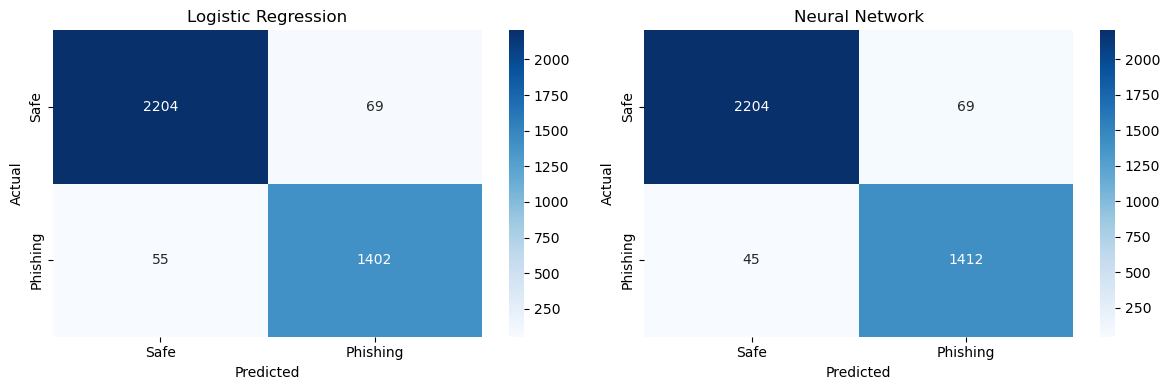

In [12]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = {
    "Logistic Regression": lr_pred,
    "Neural Network": nn_pred
}

for ax, (name, pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d",
                cmap="Blues", ax=ax,
                xticklabels=["Safe", "Phishing"],
                yticklabels=["Safe", "Phishing"])
    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [13]:
import joblib
import os

os.makedirs("../models", exist_ok=True)
joblib.dump(lr_model, "../models/lr_model.pkl")
joblib.dump(tfidf, "../models/tfidf.pkl")
print("Model saved!")
print(f"Size: {os.path.getsize('../models/lr_model.pkl') / (1024*1024):.2f} MB")

Model saved!
Size: 0.04 MB
